## K-Medoids Clustering

### Within-Cluster Sum of Squares

### Using Manhattan Distance

In [19]:
import numpy as np
import matplotlib.pyplot as plt

class KMedoids:
    def __init__(self, n_clusters, max_iters=100):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.history = []  # To store the history of medoids and labels for plotting

    def fit(self, X):
        # Randomly initialize medoids
        np.random.seed(41)
        random_indices = np.random.choice(len(X), self.n_clusters, replace=False)
        self.medoids = X[random_indices]

        for _ in range(self.max_iters):
            # Assign clusters
            distances = self._compute_distances(X)
            self.labels = np.argmin(distances, axis=1)

            # Store current state for plotting
            self.history.append((X.copy(), self.medoids.copy(), self.labels.copy()))

            # Update medoids
            new_medoids = np.array([self._find_best_medoid(X[self.labels == i]) for i in range(self.n_clusters)])

            # Check for convergence
            if np.all(self.medoids == new_medoids):
                break

            self.medoids = new_medoids

    def _compute_distances(self, X):
        """Compute Manhattan distances from data points to medoids."""
        distances = np.zeros((X.shape[0], self.n_clusters))
        for i in range(self.n_clusters):
            distances[:, i] = np.sum(np.abs(X - self.medoids[i]), axis=1)
        return distances

    def _find_best_medoid(self, cluster):
        """Find the best medoid in a given cluster."""
        distances = np.sum(self._compute_distances(cluster), axis=1)
        return cluster[np.argmin(distances)]

    def predict(self, X):
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)

def generate_data(n_samples=100):
    """Generate synthetic data for clustering."""
    np.random.seed(0)
    cluster_1 = np.random.normal(loc=0, scale=0.5, size=(n_samples // 2, 2))
    cluster_2 = np.random.normal(loc=3, scale=0.5, size=(n_samples // 2, 2))
    return np.vstack((cluster_1, cluster_2))

def plot_kmedoids_iterations(history):
    """Plot K-Medoids clustering iterations."""
    for i, (X, medoids, labels) in enumerate(history):
        plt.figure(figsize=(8, 6))
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)
        plt.scatter(medoids[:, 0], medoids[:, 1], c='red', marker='X', s=200, label='Medoids')
        plt.title(f"K-Medoids Clustering - Iteration {i + 1}")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.grid(True)
        plt.savefig(f"k_medoids_out/kmedoids_iteration_{i + 1}.png")  # Save each plot as a PNG file
        plt.close()  # Close the plot to save memoryimport numpy as np
import matplotlib.pyplot as plt
import os

class KMedoids:
    def __init__(self, n_clusters, max_iters=100):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.history = []  # To store the history of medoids and labels for plotting

    def fit(self, X):
        # Randomly initialize medoids
        np.random.seed(41)
        random_indices = np.random.choice(len(X), self.n_clusters, replace=False)
        self.medoids = X[random_indices]

        for _ in range(self.max_iters):
            # Assign clusters
            distances = self._compute_distances(X)
            self.labels = np.argmin(distances, axis=1)

            # Store current state for plotting
            self.history.append((X.copy(), self.medoids.copy(), self.labels.copy()))

            # Update medoids
            new_medoids = np.array([self._find_best_medoid(X[self.labels == i]) for i in range(self.n_clusters)])

            # Check for convergence
            if np.all(self.medoids == new_medoids):
                break

            self.medoids = new_medoids

    def _compute_distances(self, X):
        """Compute Manhattan distances from data points to medoids."""
        distances = np.zeros((X.shape[0], self.n_clusters))
        for i in range(self.n_clusters):
            distances[:, i] = np.sum(np.abs(X - self.medoids[i]), axis=1)
        return distances

    def _find_best_medoid(self, cluster):
        """Find the best medoid in a given cluster."""
        distances = np.sum(self._compute_distances(cluster), axis=1)
        return cluster[np.argmin(distances)]

    def predict(self, X):
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)

def generate_data(n_samples=100):
    """Generate synthetic data for clustering."""
    np.random.seed(0)
    cluster_1 = np.random.normal(loc=0, scale=0.5, size=(n_samples // 2, 2))
    cluster_2 = np.random.normal(loc=3, scale=0.5, size=(n_samples // 2, 2))
    return np.vstack((cluster_1, cluster_2))

def plot_kmedoids_iterations(history):
    """Plot K-Medoids clustering iterations."""
    # Create output directory if it doesn't exist
    output_dir = "k_medoids_out"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    for i, (X, medoids, labels) in enumerate(history):
        plt.figure(figsize=(8, 6))
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)
        plt.scatter(medoids[:, 0], medoids[:, 1], c='red', marker='X', s=200, label='Medoids')
        plt.title(f"K-Medoids Clustering - Iteration {i + 1}")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.grid(True)
        plt.savefig(f"{output_dir}/kmedoids_iteration_{i + 1}.png")  # Save each plot as a PNG file
        plt.close()  # Close the plot to save memory

# Generate synthetic data
X = generate_data(n_samples=100)

# Run K-Medoids
kmedoids = KMedoids(n_clusters=2)
kmedoids.fit(X)

# Plot the iterations
plot_kmedoids_iterations(kmedoids.history)

print("K-Medoids clustering iterations saved as PNG files.")

# Generate synthetic data
X = generate_data(n_samples=100)

# Run K-Medoids
kmedoids = KMedoids(n_clusters=2)
kmedoids.fit(X)

# Plot the iterations
plot_kmedoids_iterations(kmedoids.history)

print("K-Medoids clustering iterations saved as PNG files.")


K-Medoids clustering iterations saved as PNG files.
K-Medoids clustering iterations saved as PNG files.


### Agglomerative Hierarchical Clustering

### Different Linkage Methods

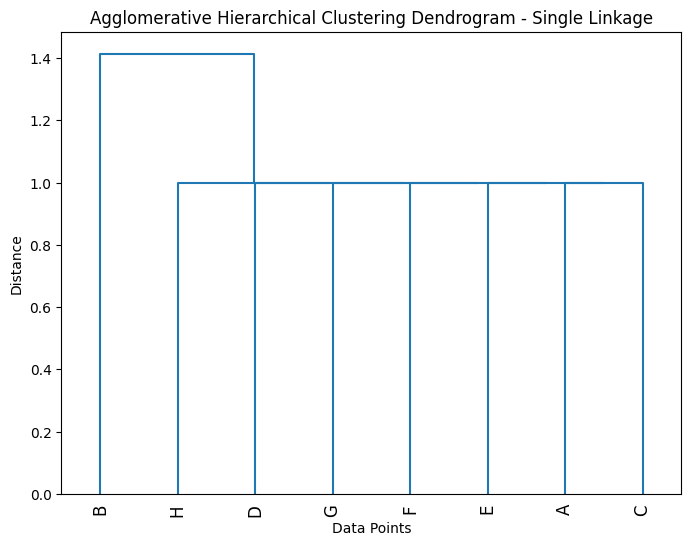

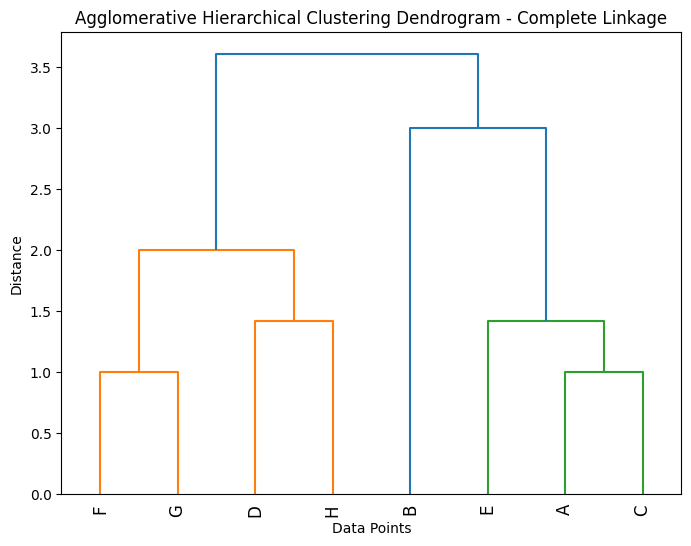

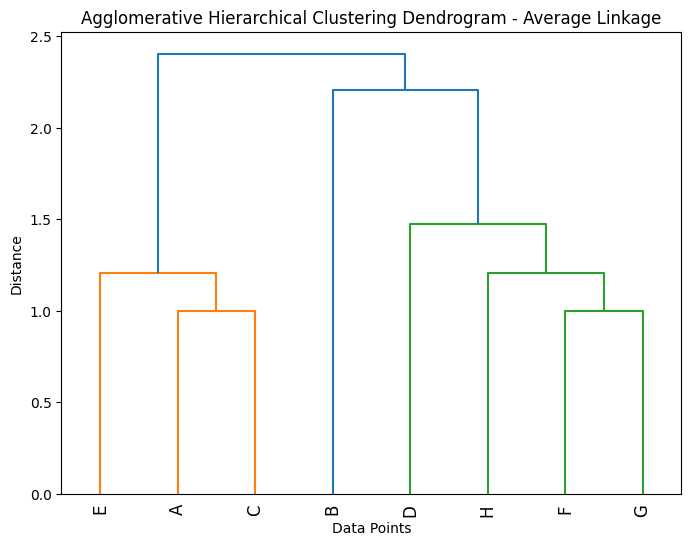

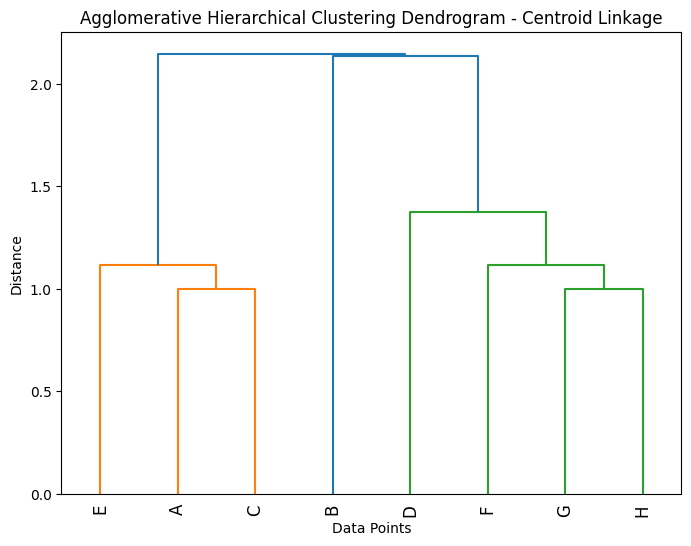

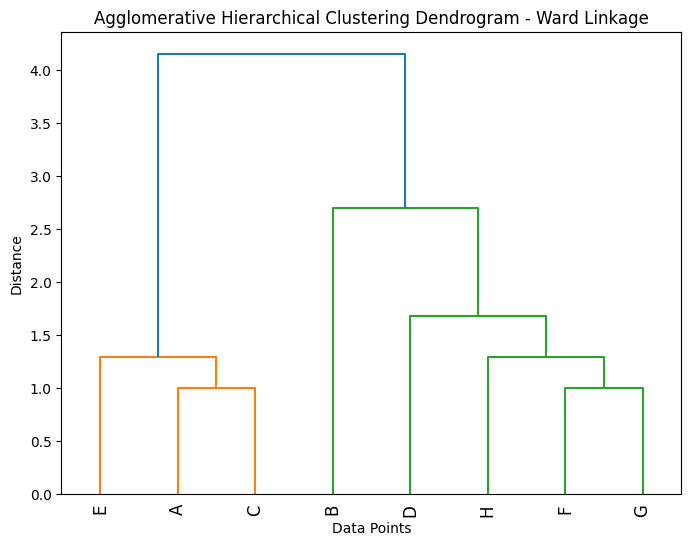

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Sample data
data = np.array([[1, 2], [1, 4], [2, 2], [4, 3], [1, 1], [2, 3], [3, 3], [3, 4]])

# Create a function to plot dendrograms
def plot_dendrogram(linkage_matrix, method_name):
    plt.figure(figsize=(8, 6))
    dendrogram(linkage_matrix, labels=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'], leaf_rotation=90)
    plt.title(f"Agglomerative Hierarchical Clustering Dendrogram - {method_name} Linkage")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.show()

# Single Linkage
linkage_complete = linkage(data, method='single')
plot_dendrogram(linkage_complete, 'Single')

# Complete Linkage
linkage_complete = linkage(data, method='complete')
plot_dendrogram(linkage_complete, 'Complete')

# Average Linkage
linkage_average = linkage(data, method='average')
plot_dendrogram(linkage_average, 'Average')

# Centroid Linkage
linkage_centroid = linkage(data, method='centroid')
plot_dendrogram(linkage_centroid, 'Centroid')

# Ward's Linkage
linkage_ward = linkage(data, method='ward')
plot_dendrogram(linkage_ward, 'Ward')


### Visualising Clusters

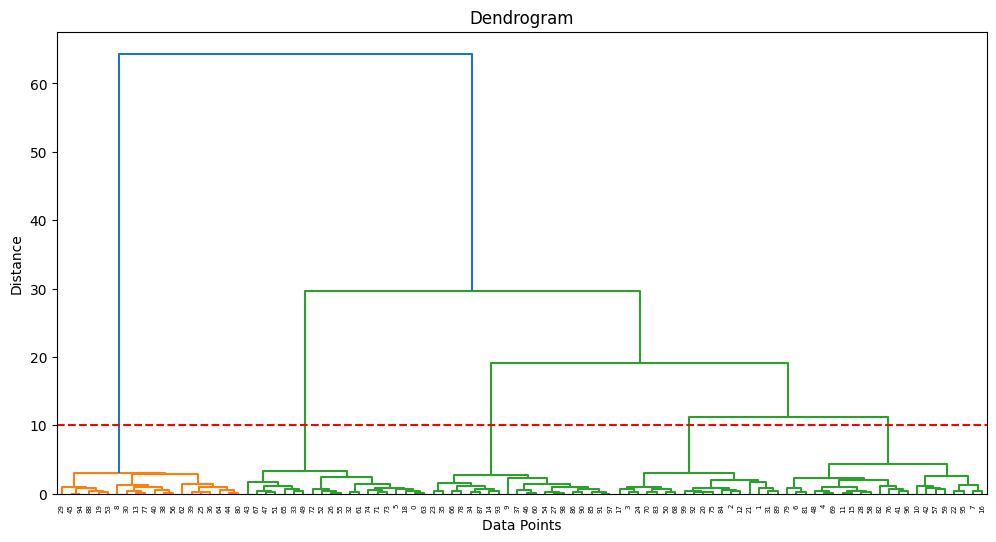

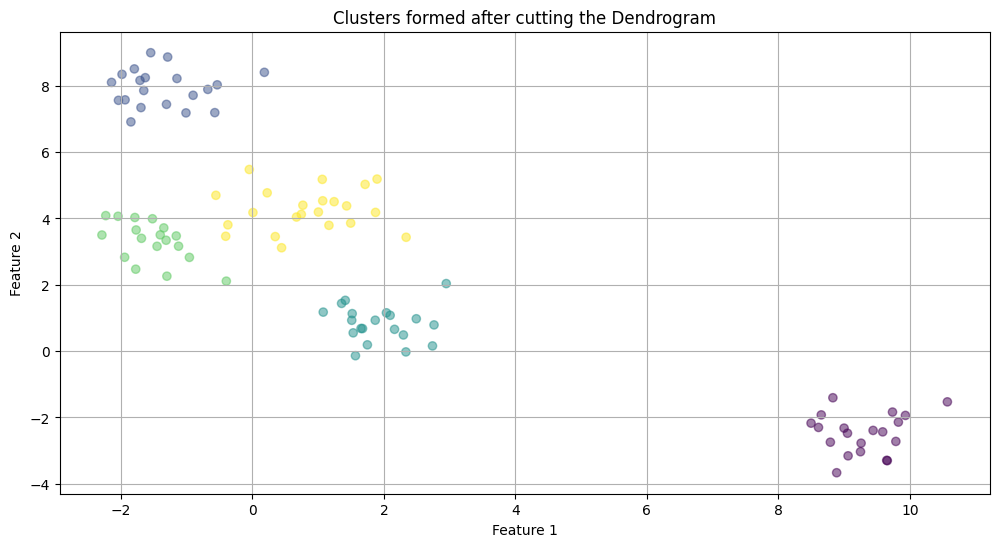

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs

# Generate synthetic data
n_samples = 100
n_features = 2
n_clusters = 5
X, y = make_blobs(n_samples=n_samples, centers=n_clusters, cluster_std=0.60, random_state=0)

# Perform hierarchical clustering using Ward's method
Z = linkage(X, method='ward')

# Function to plot dendrogram
def plot_dendrogram(Z, cutoff=None):
    plt.figure(figsize=(12, 6))
    dendrogram(Z, leaf_rotation=90)
    if cutoff:
        plt.axhline(y=cutoff, color='r', linestyle='--')
    plt.title("Dendrogram")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.show()

# Plot the dendrogram
cutoff_height = 10  # You can adjust this height
plot_dendrogram(Z, cutoff=cutoff_height)

# Create clusters based on the cutoff
clusters = fcluster(Z, t=cutoff_height, criterion='distance')

# Visualizing the clusters
plt.figure(figsize=(12, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.title("Clusters formed after cutting the Dendrogram")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


### Divisive Hierarchical Clustering

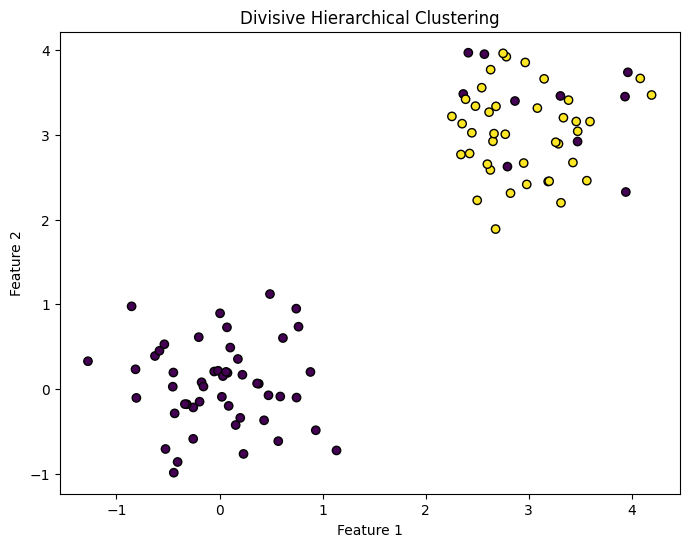

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

class DivisiveHierarchicalClustering:
    def __init__(self, n_clusters=2):
        self.n_clusters = n_clusters
        self.labels = None

    def fit(self, X):
        # Start with one cluster containing all the data
        clusters = [X]
        while len(clusters) < self.n_clusters:
            # Find the cluster with the largest variance
            variances = [np.var(cluster, axis=0).sum() for cluster in clusters]
            max_variance_index = np.argmax(variances)
            cluster_to_split = clusters[max_variance_index]

            # Compute pairwise distances and find the split
            pairwise_distances = pdist(cluster_to_split)
            linkage_matrix = linkage(pairwise_distances, method='ward')

            # Split the cluster into two subclusters
            new_clusters = self._split_cluster(cluster_to_split, linkage_matrix)

            # Replace the old cluster with the two new clusters
            clusters.pop(max_variance_index)
            clusters.extend(new_clusters)

        self.labels = self._assign_labels(X, clusters)

    def _split_cluster(self, cluster, linkage_matrix):
        # Perform a simple cut to divide the cluster into two subclusters
        # Using the first two entries in the linkage matrix for simplicity
        return np.split(cluster, [int(linkage_matrix[0, 0])])

    def _assign_labels(self, X, clusters):
        labels = np.empty(X.shape[0], dtype=int)
        for cluster_index, cluster in enumerate(clusters):
            for point in cluster:
                labels[np.all(X == point, axis=1)] = cluster_index
        return labels

    def get_labels(self):
        return self.labels

# Generate sample data
def generate_data(n_samples=100):
    """Generate synthetic data for clustering."""
    np.random.seed(0)
    cluster_1 = np.random.normal(loc=0, scale=0.5, size=(n_samples // 2, 2))
    cluster_2 = np.random.normal(loc=3, scale=0.5, size=(n_samples // 2, 2))
    return np.vstack((cluster_1, cluster_2))

# Plotting function for clusters
def plot_clusters(X, labels):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k')
    plt.title('Divisive Hierarchical Clustering')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Example usage
if __name__ == "__main__":
    X = generate_data(n_samples=100)
    div_hc = DivisiveHierarchicalClustering(n_clusters=2)
    div_hc.fit(X)
    labels = div_hc.get_labels()
    plot_clusters(X, labels)


### DBSCAN clustering algorithm

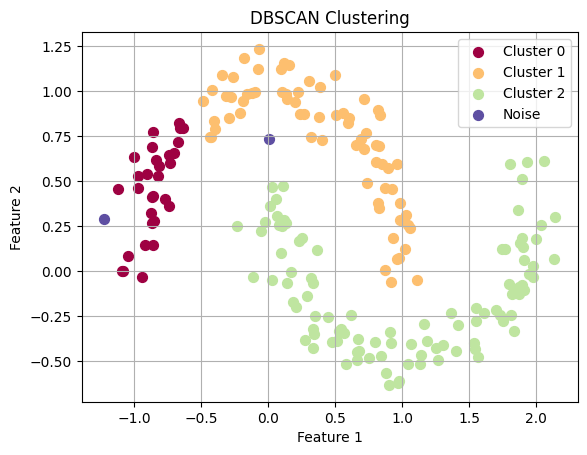

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Generate synthetic dataset
def generate_data():
    # Create a dataset with two interleaving half circles (moons)
    X, _ = make_moons(n_samples=200, noise=0.1, random_state=42)
    return X

# Apply DBSCAN
def apply_dbscan(X, eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)
    return labels

# Plotting function for DBSCAN results
def plot_dbscan(X, labels):
    unique_labels = set(labels)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
    
    for k, col in zip(unique_labels, colors):
        class_member_mask = (labels == k)
        
        # Plotting core samples
        xy = X[class_member_mask]
        plt.scatter(xy[:, 0], xy[:, 1], s=50, color=col, label=f'Cluster {k}' if k != -1 else 'Noise')

    plt.title('DBSCAN Clustering')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()

# Main execution
if __name__ == "__main__":
    # Generate data
    X = generate_data()
    
    # Apply DBSCAN with specified parameters
    eps = 0.2         # Maximum distance between two samples for one to be considered as in the neighborhood of the other
    min_samples = 5   # Minimum number of samples in a neighborhood for a point to be considered a core point
    labels = apply_dbscan(X, eps, min_samples)
    
    # Plot the results
    plot_dbscan(X, labels)


### Evaluating Clustering Algorithms - Intrinsic Metrics

### Silhouette Score

In [24]:
import numpy as np

# Define the points in each cluster
cluster_1 = np.array([(2, 5), (3, 4), (4, 6)])
cluster_2 = np.array([(8, 3), (9, 2), (10, 5)])
cluster_3 = np.array([(6, 10), (7, 8), (8, 9)])

# Combine all points into one dataset
all_points = np.vstack((cluster_1, cluster_2, cluster_3))

# Function to calculate Euclidean distance
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

# Function to calculate the silhouette score for each point
def silhouette_score(all_points, labels):
    scores = []
    n = len(all_points)

    for i in range(n):
        # Find the current point
        current_point = all_points[i]
        
        # Find the label of the current point
        current_label = labels[i]
        
        # Calculate a (average distance to the same cluster)
        same_cluster_distances = [
            euclidean_distance(current_point, all_points[j])
            for j in range(n) if labels[j] == current_label and j != i
        ]
        a = np.mean(same_cluster_distances) if same_cluster_distances else 0
        
        # Calculate b (minimum average distance to other clusters)
        other_cluster_distances = []
        for label in set(labels):
            if label != current_label:
                distances = [
                    euclidean_distance(current_point, all_points[j])
                    for j in range(n) if labels[j] == label
                ]
                if distances:
                    other_cluster_distances.append(np.mean(distances))

        b = min(other_cluster_distances) if other_cluster_distances else 0
        
        # Calculate the silhouette score for this point
        score = (b - a) / max(a, b) if max(a, b) != 0 else 0
        scores.append(score)

    return np.array(scores)

# Labels for the points in all_points
labels = np.array([1]*3 + [2]*3 + [3]*3)  # Cluster 1: label 1, Cluster 2: label 2, Cluster 3: label 3

# Calculate the silhouette scores
scores = silhouette_score(all_points, labels)

# Print the silhouette scores for each point and the average score
for i, score in enumerate(scores):
    print(f"Point {i + 1}: Silhouette Score = {score:.4f}")

average_score = np.mean(scores)
print(f"\nAverage Silhouette Score: {average_score:.4f}")


Point 1: Silhouette Score = 0.7184
Point 2: Silhouette Score = 0.7039
Point 3: Silhouette Score = 0.4870
Point 4: Silhouette Score = 0.6125
Point 5: Silhouette Score = 0.6626
Point 6: Silhouette Score = 0.4056
Point 7: Silhouette Score = 0.6185
Point 8: Silhouette Score = 0.6372
Point 9: Silhouette Score = 0.6879

Average Silhouette Score: 0.6149


### Davies-Bouldin Index

In [25]:
import numpy as np

# Function to calculate Euclidean distance
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

# Function to calculate the centroid of a cluster
def calculate_centroid(cluster):
    return np.mean(cluster, axis=0)

# Function to calculate the intra-cluster distance for each cluster
def calculate_intra_distance(cluster, centroid):
    return np.mean([euclidean_distance(point, centroid) for point in cluster])

# Function to calculate the Davies-Bouldin Index
def davies_bouldin_index(clusters):
    n_clusters = len(clusters)
    centroids = [calculate_centroid(cluster) for cluster in clusters]
    
    # Calculate intra-cluster distances
    S = [calculate_intra_distance(clusters[i], centroids[i]) for i in range(n_clusters)]

    # Calculate the Davies-Bouldin Index
    DBI = 0
    for i in range(n_clusters):
        max_ratio = 0
        for j in range(n_clusters):
            if i != j:
                M_ij = euclidean_distance(centroids[i], centroids[j])
                ratio = (S[i] + S[j]) / M_ij
                max_ratio = max(max_ratio, ratio)
        print(i+1, max_ratio)
        DBI += max_ratio
    
    # Return average DBI
    return DBI / n_clusters

# Example data: a list of clusters with points
clusters = [
    np.array([[2, 5], [3, 4], [4, 6]]),  # Cluster 1
    np.array([[8, 3], [9, 2], [10, 5]]),  # Cluster 2
    np.array([[6, 10], [7, 8], [8, 9]])   # Cluster 3
]

# Calculate Davies-Bouldin Index
db_index = davies_bouldin_index(clusters)

print(f"Davies-Bouldin Index: {db_index:.4f}")


1 0.41459587266912035
2 0.4296313927591706
3 0.4296313927591706
Davies-Bouldin Index: 0.4246


### Within-Cluster Sum of Squares

In [26]:
import numpy as np

# Function to calculate centroid of a cluster
def calculate_centroid(cluster):
    return np.mean(cluster, axis=0)

# Function to calculate WCSS for a cluster
def calculate_wcss(cluster, centroid):
    return np.sum(np.linalg.norm(cluster - centroid, axis=1) ** 2)

# Function to calculate WCSS for multiple clusters
def calculate_wcss_for_clusters(clusters):
    total_wcss = 0
    wcss_per_cluster = {}
    
    # Iterate over each cluster
    for i, cluster in enumerate(clusters):
        centroid = calculate_centroid(cluster)
        wcss = calculate_wcss(cluster, centroid)
        wcss_per_cluster[f"Cluster {i + 1}"] = wcss
        total_wcss += wcss  # Accumulate total WCSS
    
    return wcss_per_cluster, total_wcss

# Example usage
# Define multiple clusters (can be any number of clusters)
clusters = [
    np.array([[2, 5], [3, 4], [4, 6]]),  # Cluster 1
    np.array([[8, 3], [9, 2], [10, 5]]),  # Cluster 2
    np.array([[6, 10], [7, 8], [8, 9]]),  # Cluster 3
]

# Calculate WCSS for all clusters
wcss_per_cluster, total_wcss = calculate_wcss_for_clusters(clusters)

# Print the WCSS results
for cluster, wcss in wcss_per_cluster.items():
    print(f"{cluster} WCSS: {wcss:.4f}")

print(f"Total WCSS: {total_wcss:.4f}")


Cluster 1 WCSS: 4.0000
Cluster 2 WCSS: 6.6667
Cluster 3 WCSS: 4.0000
Total WCSS: 14.6667


In [27]:
import numpy as np
from itertools import combinations

def euclidean_distance(point1, point2):
    return np.linalg.norm(point1 - point2)

def cluster_diameter(cluster):
    """Calculate the diameter of a cluster."""
    max_distance = 0
    for point1, point2 in combinations(cluster, 2):
        distance = euclidean_distance(point1, point2)
        if distance > max_distance:
            max_distance = distance
    return max_distance

def min_inter_cluster_distance(clusters):
    """Calculate minimum distance between clusters."""
    min_distance = float('inf')
    for (i, cluster_a), (j, cluster_b) in combinations(enumerate(clusters), 2):
        for point_a in cluster_a:
            for point_b in cluster_b:
                distance = euclidean_distance(point_a, point_b)
                if distance < min_distance:
                    min_distance = distance
    return min_distance

def dunn_index(clusters):
    """Calculate Dunn's index for the given clusters."""
    min_distance = min_inter_cluster_distance(clusters)
    max_diameter = max(cluster_diameter(cluster) for cluster in clusters)
    return min_distance / max_diameter

# Define clusters as numpy arrays
clusters = [
    np.array([[2, 5], [3, 4], [4, 6]]),  # Cluster 1
    np.array([[8, 3], [9, 2], [10, 5]]),  # Cluster 2
    np.array([[6, 10], [7, 8], [8, 9]])   # Cluster 3
]

# Calculate Dunn's index
dunn_index_value = dunn_index(clusters)
print(f"Dunn's Index: {dunn_index_value:.4f}")

Dunn's Index: 1.1402


### Evaluating Clustering Algorithms - Extrinsic Metrics

### Contingency Matrix

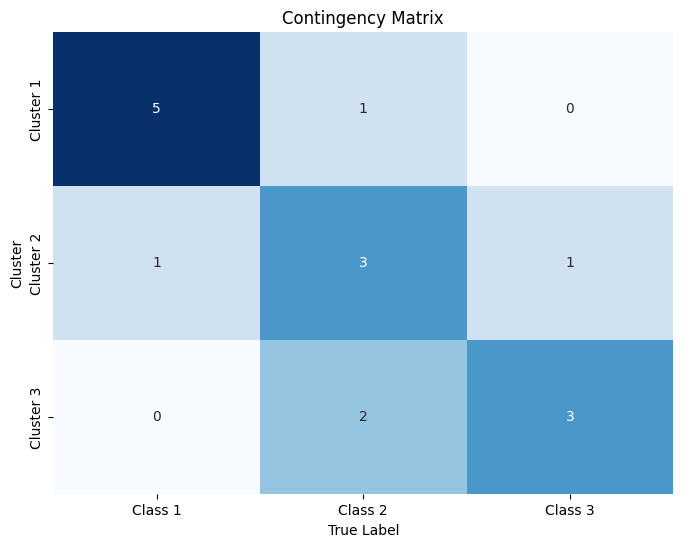

True Label  Class 1  Class 2  Class 3
Cluster                              
Cluster 1         5        1        0
Cluster 2         1        3        1
Cluster 3         0        2        3


In [28]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Sample dataset creation based on the provided contingency matrix
data = {
    "Cluster": ["Cluster 1"] * 5 + ["Cluster 1"] * 1 + ["Cluster 2"] * 1 + ["Cluster 2"] * 3 + ["Cluster 2"] * 1 + ["Cluster 3"] * 2 + ["Cluster 3"] * 3,
    "True Label": ["Class 1"] * 5 + ["Class 2"] * 1 + ["Class 1"] * 1 + ["Class 2"] * 3 + ["Class 3"] * 1 + ["Class 2"] * 2 + ["Class 3"] * 3
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Display contingency matrix (confusion matrix) using sklearn and seaborn
def display_contingency_matrix(df, cluster_column, label_column):
    # Generate contingency matrix
    contingency = pd.crosstab(df[cluster_column], df[label_column])
    
    # Plot the contingency matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Contingency Matrix")
    plt.xlabel("True Label")
    plt.ylabel("Cluster")
    plt.show()
    
    return contingency

# Call the function and display the contingency matrix
contingency_matrix_result = display_contingency_matrix(df, "Cluster", "True Label")
print(contingency_matrix_result)


### Purity

In [29]:
# Function to calculate and print purity for each cluster and overall purity
def calculate_purity(df, cluster_column, label_column):
    # Generate the contingency matrix
    contingency = pd.crosstab(df[cluster_column], df[label_column])
    
    # Initialize variables for calculating overall purity
    total_points = len(df)
    weighted_purity_sum = 0

    print("Purity of each cluster:")
    
    # Calculate purity for each cluster
    for cluster, row in contingency.iterrows():
        cluster_size = row.sum()
        max_class_count = row.max()
        cluster_purity = max_class_count / cluster_size
        weighted_purity_sum += max_class_count
        print(f"{cluster}: {cluster_purity:.4f}")
    
    # Calculate overall purity
    overall_purity = weighted_purity_sum / total_points
    print(f"\nOverall Purity: {overall_purity:.4f}")

# Call the function with the generated dataset
calculate_purity(df, "Cluster", "True Label")


Purity of each cluster:
Cluster 1: 0.8333
Cluster 2: 0.6000
Cluster 3: 0.6000

Overall Purity: 0.6875


In [30]:
### Rand Index

In [31]:
import pandas as pd
from scipy.special import comb

# Function to calculate and print Rand Index for clustering
def calculate_rand_index(df, cluster_column, label_column):
    # Generate the contingency matrix
    contingency = pd.crosstab(df[cluster_column], df[label_column])
    
    # Total number of data points
    total_points = len(df)
    total_pairs = comb(total_points, 2)
    
    # Calculate True Positives (TP): Pairs in the same cluster and same class
    tp = sum(comb(n_ij, 2) for n_ij in contingency.values.flatten() if n_ij >= 2)
    
    # Calculate pairs within the same cluster (regardless of class) for False Positives (FP)
    sum_ai_2 = sum(comb(row_sum, 2) for row_sum in contingency.sum(axis=1) if row_sum >= 2)
    fp = sum_ai_2 - tp  # FP are same-cluster, different-class pairs
    
    # Calculate pairs within the same class (regardless of cluster) for False Negatives (FN)
    sum_bj_2 = sum(comb(col_sum, 2) for col_sum in contingency.sum(axis=0) if col_sum >= 2)
    fn = sum_bj_2 - tp  # FN are same-class, different-cluster pairs
    
    # True Negatives (TN): Pairs in different clusters and different classes
    tn = total_pairs - (tp + fp + fn)
    
    # Calculate the Rand Index
    rand_index = (tp + tn) / total_pairs
    
    print(f"Rand Index: {rand_index:.4f}")

# Call the function with the generated dataset
calculate_rand_index(df, "Cluster", "True Label")

Rand Index: 0.6917


### Adjusted Rand Index

In [32]:
import pandas as pd
from scipy.special import comb

# Sample dataset creation based on the provided contingency matrix
data = {
    "Cluster": ["Cluster 1"] * 5 + ["Cluster 1"] * 1 + ["Cluster 2"] * 1 + ["Cluster 2"] * 3 + ["Cluster 2"] * 1 + ["Cluster 3"] * 2 + ["Cluster 3"] * 3,
    "True Label": ["Class 1"] * 5 + ["Class 2"] * 1 + ["Class 1"] * 1 + ["Class 2"] * 3 + ["Class 3"] * 1 + ["Class 2"] * 2 + ["Class 3"] * 3
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Function to calculate and print Adjusted Rand Index (ARI) for clustering
def calculate_ari(df, cluster_column, label_column):
    # Generate the contingency matrix
    contingency = pd.crosstab(df[cluster_column], df[label_column])
    
    # Total number of data points
    total_points = len(df)
    total_pairs = comb(total_points, 2)
    
    # Calculate each component for the ARI formula
    sum_nij_2 = sum(comb(n_ij, 2) for n_ij in contingency.values.flatten() if n_ij >= 2)
    sum_ai_2 = sum(comb(row_sum, 2) for row_sum in contingency.sum(axis=1) if row_sum >= 2)
    sum_bj_2 = sum(comb(col_sum, 2) for col_sum in contingency.sum(axis=0) if col_sum >= 2)
    
    # Expected index calculation
    expected_index = (sum_ai_2 * sum_bj_2) / total_pairs
    
    # Calculate the ARI numerator and denominator
    numerator = sum_nij_2 - expected_index
    denominator = 0.5 * (sum_ai_2 + sum_bj_2) - expected_index
    
    # Adjusted Rand Index
    ari = numerator / denominator if denominator != 0 else 1.0
    
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")

# Call the function with the generated dataset
calculate_ari(df, "Cluster", "True Label")


Adjusted Rand Index (ARI): 0.2600
